# Credit Card Customer Segmentation
## Unsupervised Machine Learning Project

**Dataset:** CC_GENERAL.csv  
**Goal:** Discover customer segments based on credit card usage behavior

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 1. Dataset Overview

In [70]:
df = pd.read_csv("CC GENERAL.csv")
print("shape",df.shape)
df.head

shape (8950, 18)


<bound method NDFrame.head of      CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  P

In [71]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [72]:
# Statistical summary
df.describe().round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


## 2. Missing Values

In [73]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count':missing,
    'Percentage':missing_percent
})

print(missing_df[missing_df['Missing Count']>0])

                  Missing Count  Percentage
CREDIT_LIMIT                  1    0.011173
MINIMUM_PAYMENTS            313    3.497207


In [74]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


## 3. Feature Distributions

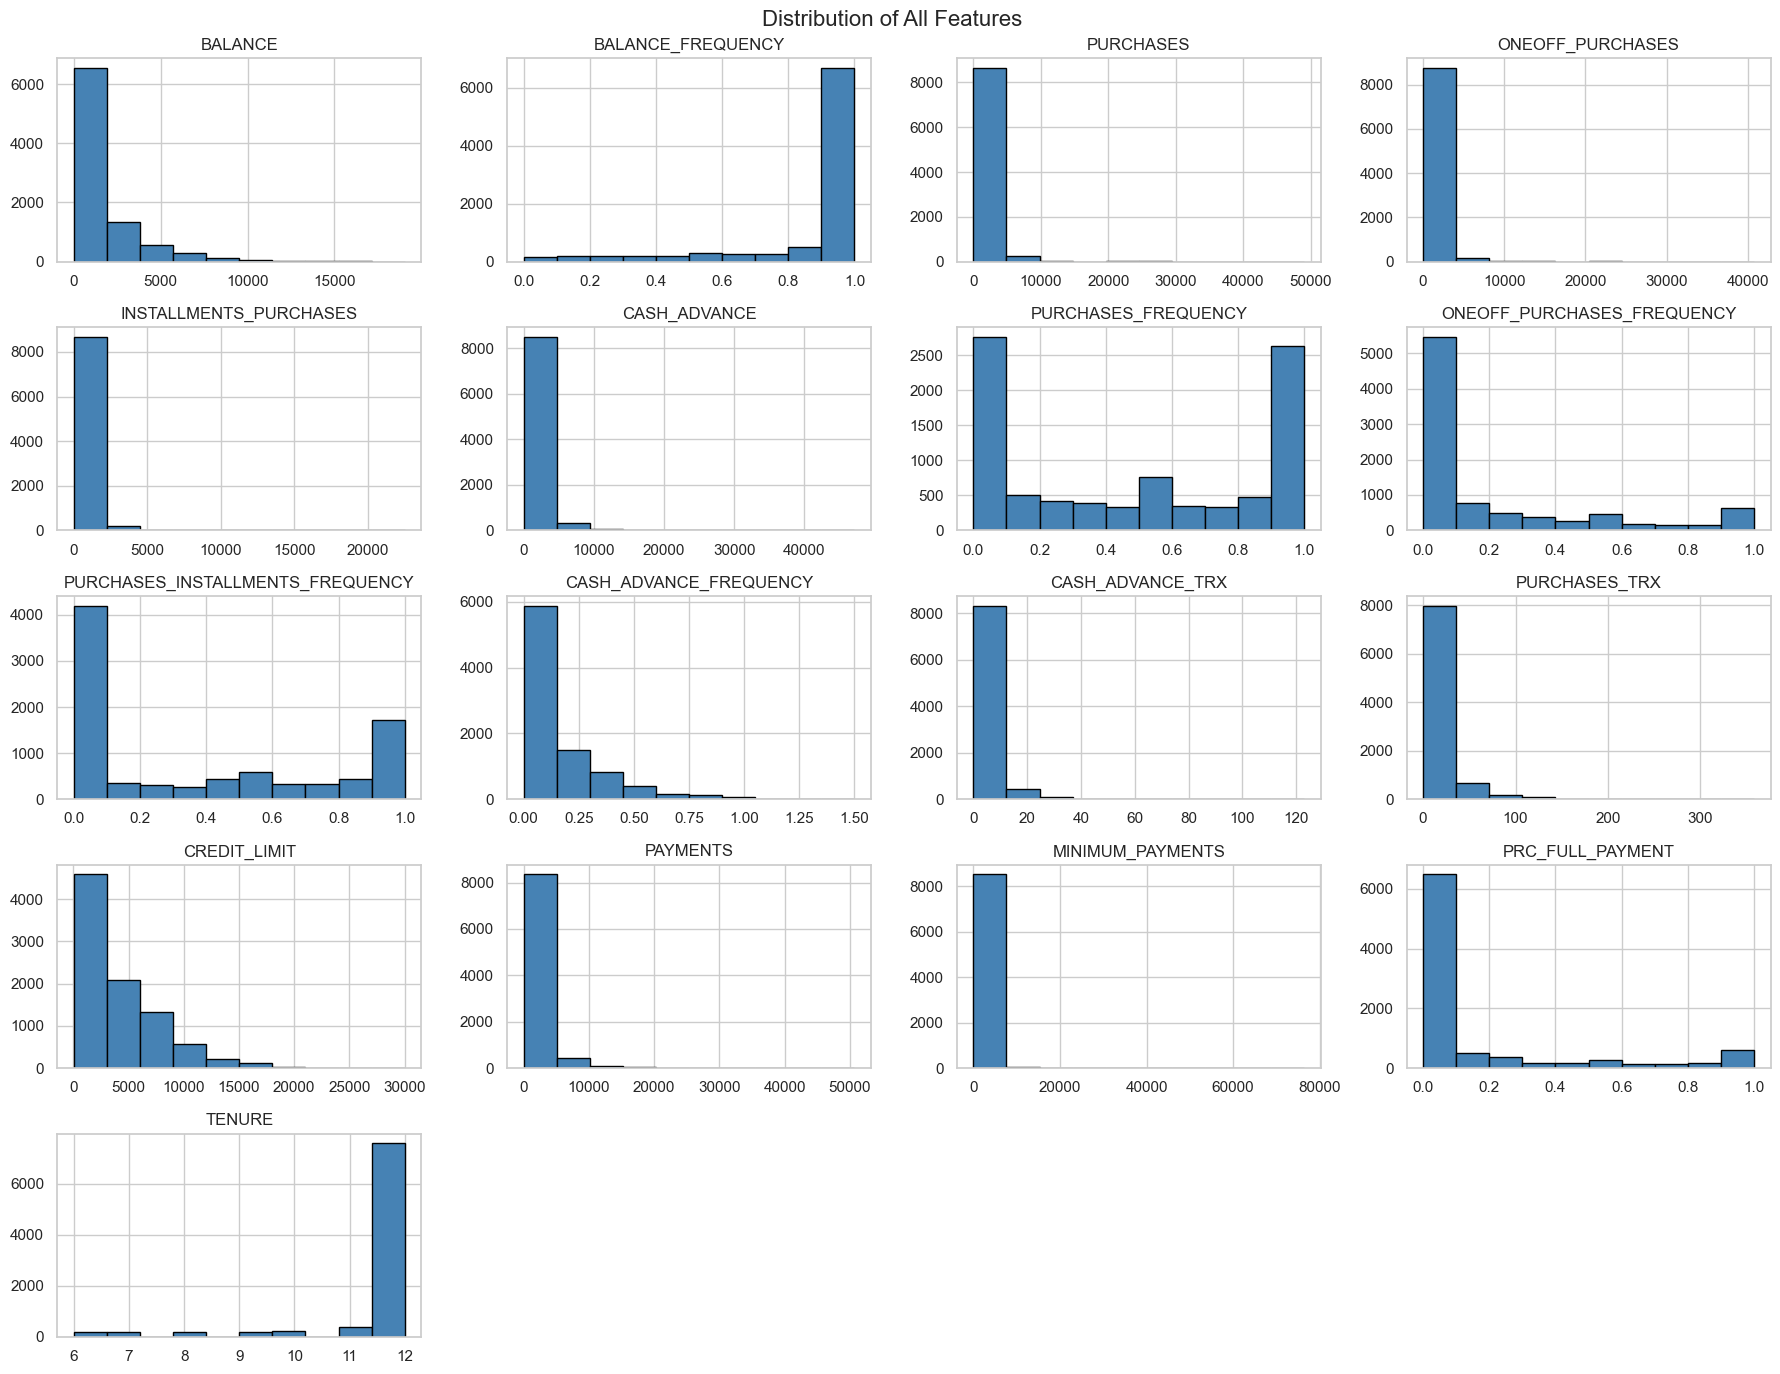

In [75]:
df.drop('CUST_ID',axis=1).hist(figsize=(18,14),color='steelblue',edgecolor='black')
plt.suptitle('Distribution of All Features',fontsize = 16)
plt.tight_layout()
plt.savefig(r"C:\Users\user\OneDrive\Desktop\ML\Credit Card\outputs\reports\feature_distributions.png")

## 4. Outlier Detection

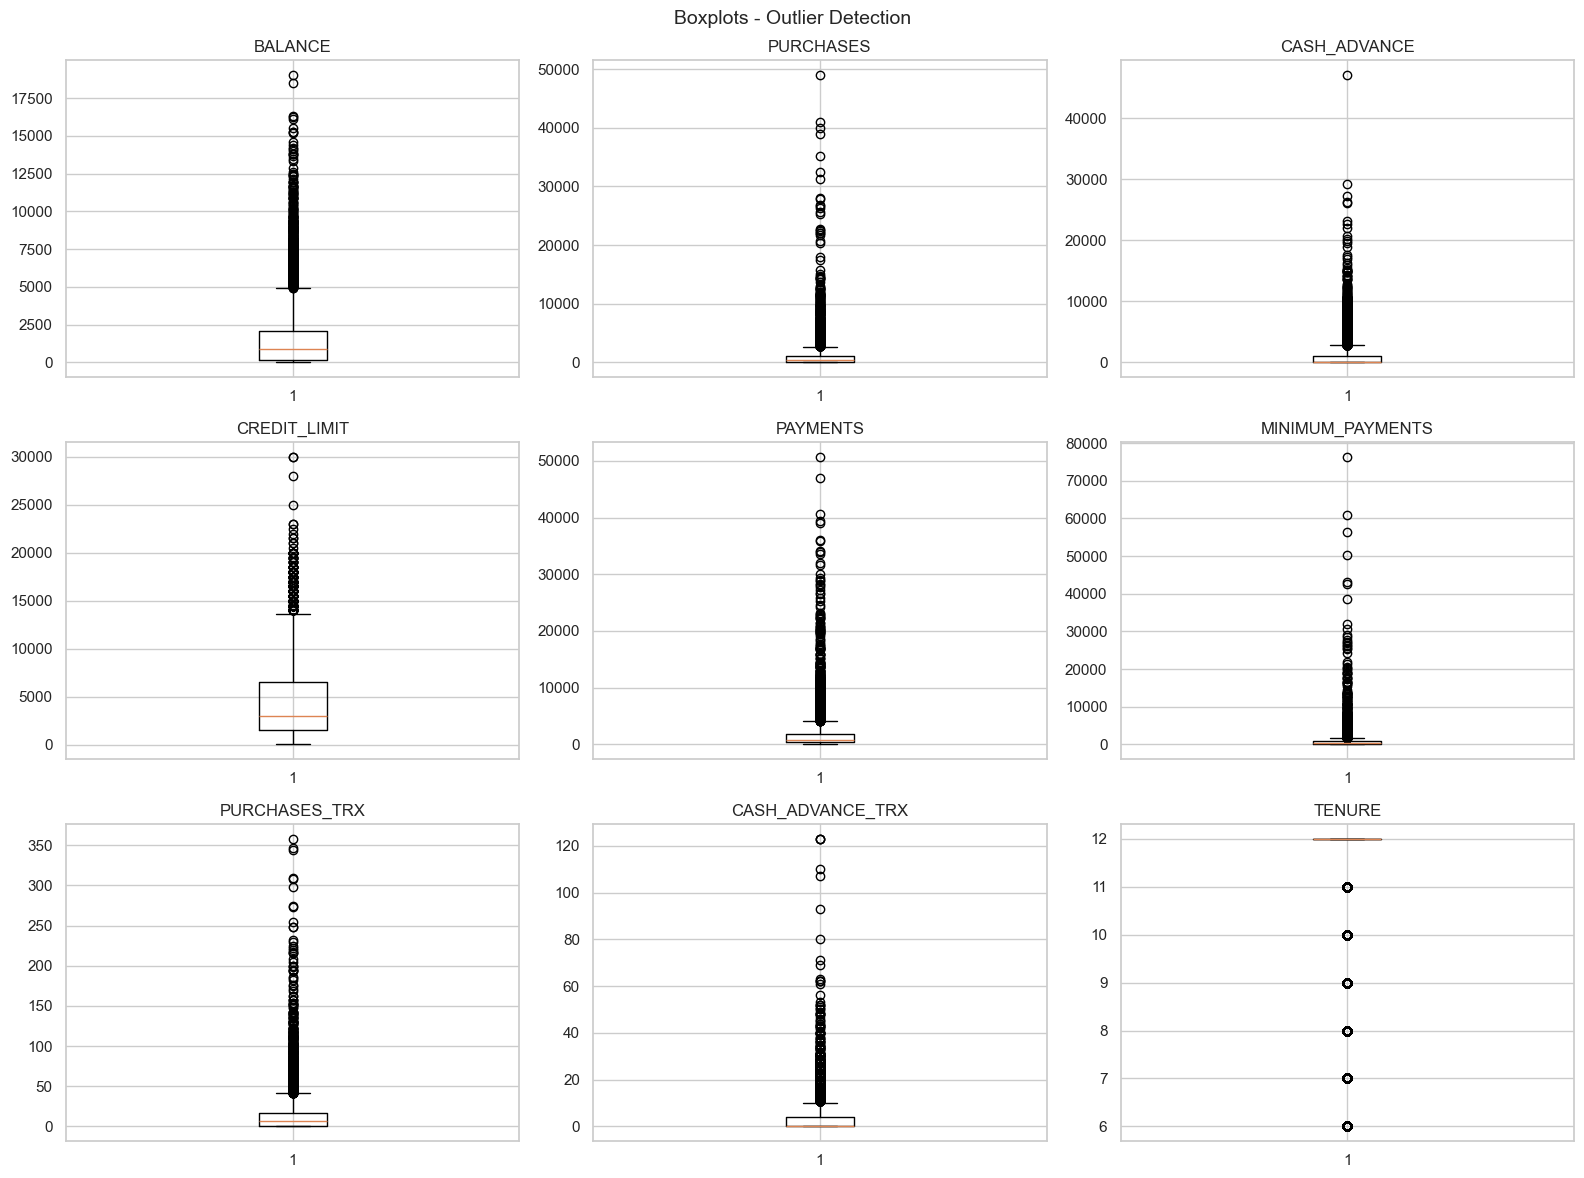

In [76]:
fig,axes = plt.subplots(3,3,figsize=(16,12))
cols = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','PURCHASES_TRX','CASH_ADVANCE_TRX','TENURE']
for i,col in enumerate(cols):
    axes[i//3][i%3].boxplot(df[col].dropna())
    axes[i//3][i%3].set_title(col)

plt.suptitle('Boxplots - Outlier Detection',fontsize =14)
plt.tight_layout()
plt.savefig(r"C:\Users\user\OneDrive\Desktop\ML\Credit Card\outputs\reports\outliers_boxplot.png")


## 5. Correlation Between Features

In [ ]:
plt.figure(figsize=(16,10))
corr = df.drop('CUST_ID',axis=1).corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap',fontsize = 14)
plt.tight_layout()
plt.savefig(r"C:\Users\user\OneDrive\Desktop\ML\Credit Card\outputs\reports\correlation_heatmap.png")


## 6. EDA Key Observations

- Dataset has **8,950 customers** and **18 features**
- **CUST_ID** is just an identifier — will be dropped during preprocessing
- **MINIMUM_PAYMENTS** has 313 missing values (~3.5%) — will fill with median
- **CREDIT_LIMIT** has 1 missing value — will fill with median
- **No duplicate rows** found
- Features like BALANCE, CASH_ADVANCE, PURCHASES are **heavily right-skewed** — will need scaling
- Strong correlation found between **PURCHASES and ONEOFF_PURCHASES**
- Strong correlation between **PURCHASES_FREQUENCY and PURCHASES_INSTALLMENTS_FREQUENCY**

## 4. Data Preprocessing

In this section we clean the raw dataset by:
- Dropping irrelevant columns
- Handling missing values
- Capping outliers